Text(750, 0.1, 'scattering')

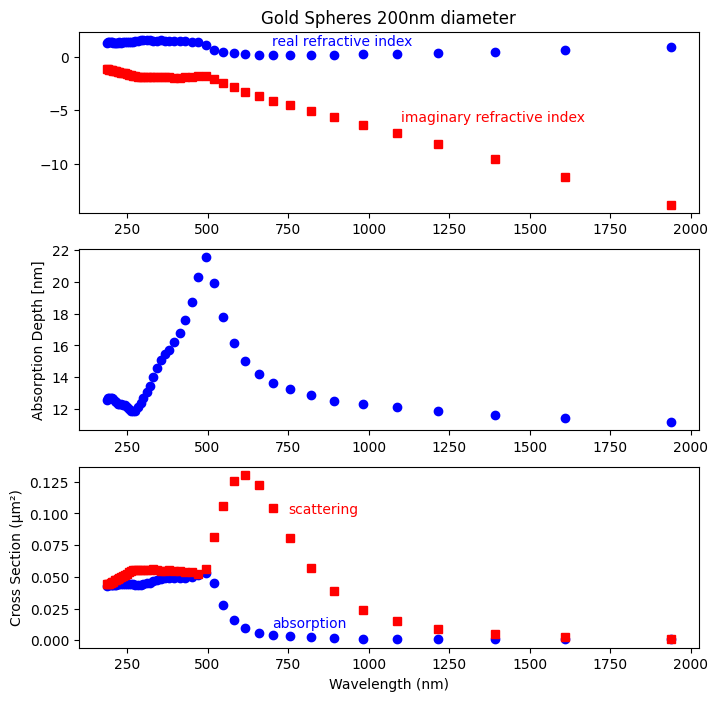

In [2]:
#!/usr/bin/env python3

"""
Plot the scattering cross section for 100nm gold spheres.

The resulting graph is as a function of wavelength.
"""

import numpy as np
import matplotlib.pyplot as plt
import miepython as mie

# from https://refractiveindex.info/?shelf = main&book = Au&page = Johnson
# wavelength in microns
ref_lam = np.array(
    [
        0.1879,
        0.1916,
        0.1953,
        0.1993,
        0.2033,
        0.2073,
        0.2119,
        0.2164,
        0.2214,
        0.2262,
        0.2313,
        0.2371,
        0.2426,
        0.2490,
        0.2551,
        0.2616,
        0.2689,
        0.2761,
        0.2844,
        0.2924,
        0.3009,
        0.3107,
        0.3204,
        0.3315,
        0.3425,
        0.3542,
        0.3679,
        0.3815,
        0.3974,
        0.4133,
        0.4305,
        0.4509,
        0.4714,
        0.4959,
        0.5209,
        0.5486,
        0.5821,
        0.6168,
        0.6595,
        0.7045,
        0.7560,
        0.8211,
        0.8920,
        0.9840,
        1.0880,
        1.2160,
        1.3930,
        1.6100,
        1.9370,
    ]
)

ref_n = np.array(
    [
        1.28,
        1.32,
        1.34,
        1.33,
        1.33,
        1.30,
        1.30,
        1.30,
        1.30,
        1.31,
        1.30,
        1.32,
        1.32,
        1.33,
        1.33,
        1.35,
        1.38,
        1.43,
        1.47,
        1.49,
        1.53,
        1.53,
        1.54,
        1.48,
        1.48,
        1.50,
        1.48,
        1.46,
        1.47,
        1.46,
        1.45,
        1.38,
        1.31,
        1.04,
        0.62,
        0.43,
        0.29,
        0.21,
        0.14,
        0.13,
        0.14,
        0.16,
        0.17,
        0.22,
        0.27,
        0.35,
        0.43,
        0.56,
        0.92,
    ]
)

ref_k = np.array(
    [
        1.188,
        1.203,
        1.226,
        1.251,
        1.277,
        1.304,
        1.350,
        1.387,
        1.427,
        1.460,
        1.497,
        1.536,
        1.577,
        1.631,
        1.688,
        1.749,
        1.803,
        1.847,
        1.869,
        1.878,
        1.889,
        1.893,
        1.898,
        1.883,
        1.871,
        1.866,
        1.895,
        1.933,
        1.952,
        1.958,
        1.948,
        1.914,
        1.849,
        1.833,
        2.081,
        2.455,
        2.863,
        3.272,
        3.697,
        4.103,
        4.542,
        5.083,
        5.663,
        6.350,
        7.150,
        8.145,
        9.519,
        11.21,
        13.78,
    ]
)

radius = 0.1  # in microns
m = ref_n - 1.0j * ref_k
x = 2 * np.pi * radius / ref_lam
cross_section_area = np.pi * radius**2
mu_a = 4 * np.pi * ref_k / ref_lam  # nm
qext, qsca, qback, g = mie.efficiencies_mx(m, x)

sca_cross_section = qsca * cross_section_area
abs_cross_section = (qext - qsca) * cross_section_area

plt.subplots(3, 1, figsize=(8, 8))
plt.subplot(311)
plt.plot(ref_lam * 1000, ref_n, "ob")
plt.plot(ref_lam * 1000, -ref_k, "sr")
plt.title("Gold Spheres 200nm diameter")
plt.text(700, 1, "real refractive index", color="blue")
plt.text(1100, -6, "imaginary refractive index", color="red")

plt.subplot(312)
plt.plot(ref_lam * 1000, 1000 / mu_a, "ob")
plt.ylabel("Absorption Depth [nm]")

plt.subplot(313)
plt.plot(ref_lam * 1000, abs_cross_section, "ob")
plt.plot(ref_lam * 1000, sca_cross_section, "sr")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Cross Section (µm²)")
plt.text(700, 0.01, "absorption", color="blue")
plt.text(750, 0.1, "scattering", color="red")
# plt.savefig("04.svg")
# plt.show()

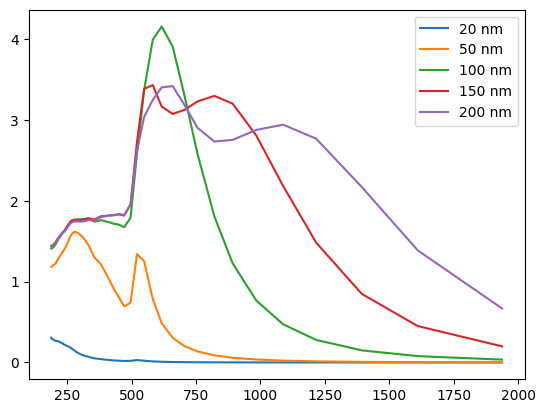

In [12]:
radii = [0.02, 0.05, 0.1, 0.15, 0.2]

for radius in radii:
    x = 2 * np.pi * radius / ref_lam

    qext, qsca, qback, g = mie.efficiencies_mx(m, x)

    sca_cross_section = qsca

    plt.plot(
        ref_lam * 1000,
        sca_cross_section,
        label=f"{radius*1000:.0f} nm",
    )
    plt.legend()

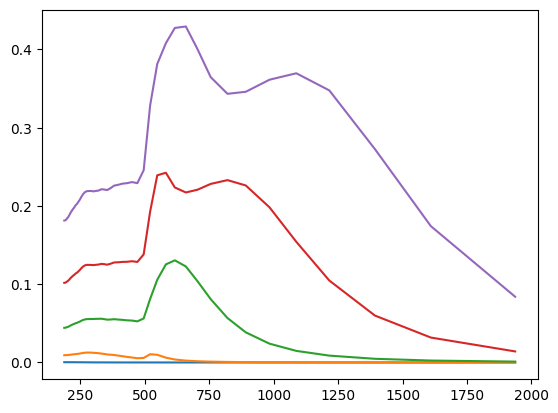

In [9]:
radii = [0.02, 0.05, 0.1, 0.15, 0.2]

for radius in radii:
    x = 2 * np.pi * radius / ref_lam

    qext, qsca, qback, g = mie.efficiencies_mx(m, x)

    sca_cross_section = qsca * np.pi * radius**2

    plt.plot(
        ref_lam * 1000,
        sca_cross_section,
        label=f"{radius*1000:.0f} nm"
    )

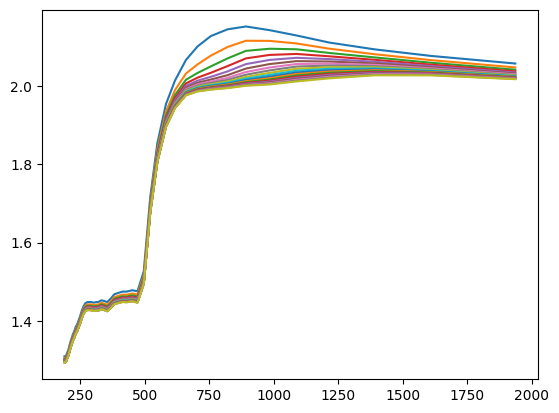

In [7]:
radii = np.arange(20, 201, 10)

for radius in radii:
    x = 2 * np.pi * radius / ref_lam

    qext, qsca, qback, g = mie.efficiencies_mx(m, x)

    sca_cross_section = qsca

    plt.plot(
        ref_lam * 1000,
        sca_cross_section,
        label=f"{radius*1000:.0f} nm"
    )